# RNN pour Prédiction PM2.5 - Beijing Air Quality

## Objectif
Ce notebook entraîne un **Recurrent Neural Network (RNN)** sur les données de qualité de l'air de Beijing pour prédire les niveaux de **PM2.5**.

## Dataset
- **Station**: Dongsi, Beijing
- **Période**: 2013-2017 (données horaires)
- **Cible**: PM2.5 (µg/m³)
- **Features**: PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM
- **Split**: 70% train / 15% validation / 15% test



In [1]:
import optuna
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# ============= CUSTOM FUNCTIONS ONLY =============
def make_sequences(data, target_col='PM2.5', seq_len=24):
    """Crée des séquences temporelles pour RNN"""
    values = data.values
    target_idx = list(data.columns).index(target_col)
    X, y = [], []
    for index in range(len(values) - seq_len):
        X.append(values[index:index + seq_len])
        y.append(values[index + seq_len, target_idx])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

class SimpleRNN(nn.Module):
    """Architecture RNN simple pour prédiction de séries temporelles"""
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.rnn(x)
        last_step = output[:, -1, :]
        return self.fc(last_step).squeeze(-1)

In [3]:
# ============= LOAD DATA =============
CSV_PATH = 'd:/100DaysofML/Notebooks/088_RNN/archive (7)/PRSA_Data_Dongsi_20130301-20170228.csv'
STATION = 'Dongsi'
TARGET_COL = 'PM2.5'
RANDOM_STATE = 42

N_TRIALS = 5
TRIAL_EPOCHS = 3
FINAL_EPOCHS = 8
PATIENCE = 3

# Charger et nettoyer avec pandas
df = pd.read_csv(CSV_PATH)
df = df[df['station'] == STATION].copy()
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values('datetime').set_index('datetime')
features = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df = df[[f for f in features if f in df.columns]].replace('NA', np.nan).astype(float).ffill().bfill()

print(f'Data shape: {df.shape}')

Data shape: (35064, 11)


In [4]:
# ============= DATASET EXPLORATION =============
print('='*70)
print('BEIJING AIR QUALITY DATASET - PM2.5 PREDICTION')
print('='*70)
print(f'\n📊 Dataset Info:')
print(f'  Station: {STATION}')
print(f'  Time range: {df.index.min()} to {df.index.max()}')
print(f'  Total samples: {len(df):,}')
print(f'  Features: {list(df.columns)}')
print(f'  Missing values: {df.isnull().sum().sum()}')

print(f'\n📈 Descriptive Statistics:')
print(df.describe().round(2))

print(f'\n🎯 Target Variable (PM2.5):')
print(f'  Mean: {df["PM2.5"].mean():.2f} µg/m³')
print(f'  Std:  {df["PM2.5"].std():.2f} µg/m³')
print(f'  Min:  {df["PM2.5"].min():.2f} µg/m³')
print(f'  Max:  {df["PM2.5"].max():.2f} µg/m³')
print(f'  Q1:   {df["PM2.5"].quantile(0.25):.2f} µg/m³')
print(f'  Q3:   {df["PM2.5"].quantile(0.75):.2f} µg/m³')

print(f'\n✅ Data prepared for RNN pipeline (train/val/test)')
print(f'  Sequence length: [12, 24, 48] hours (tuned by Optuna)')
print(f'  Split: 70% train / 15% val / 15% test')

BEIJING AIR QUALITY DATASET - PM2.5 PREDICTION

📊 Dataset Info:
  Station: Dongsi
  Time range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00
  Total samples: 35,064
  Features: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
  Missing values: 0

📈 Descriptive Statistics:
          PM2.5      PM10       SO2       NO2        CO        O3      TEMP  \
count  35064.00  35064.00  35064.00  35064.00  35064.00  35064.00  35064.00   
mean      86.31    110.58     18.53     52.19   1363.24     57.53     13.67   
std       86.34     98.18     22.97     34.48   1201.23     58.67     11.46   
min        3.00      2.00      0.29      2.00    100.00      0.64    -16.80   
25%       23.00     38.00      3.43     26.00    600.00     12.00      3.10   
50%       61.00     87.00     10.00     46.00   1000.00     44.55     14.60   
75%      120.00    151.00     24.00     72.00   1700.00     81.00     23.50   
max      737.00    955.00    300.00    258.00  10000.00   1071

In [5]:
# ============= OPTUNA OPTIMIZATION =============
def train_and_eval(df, seq_len, hidden_size, lr, batch_size, epochs):
    """Entraîne et évalue le modèle RNN"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Normalize & sequences
    scaler = StandardScaler()
    scaled = pd.DataFrame(scaler.fit_transform(df), index=df.index, columns=df.columns)
    X, y = make_sequences(scaled, target_col=TARGET_COL, seq_len=seq_len)
    
    # Split: 70% train, 15% val, 15% test
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)
    
    # DataLoaders
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    # Model & training
    model = SimpleRNN(input_size=X.shape[2], hidden_size=hidden_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    # Evaluation
    model.eval()
    def get_metrics(loader):
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(device)
                pred = model(xb)
                preds.append(pred.cpu().numpy())
                trues.append(yb.numpy())
        preds, trues = np.concatenate(preds), np.concatenate(trues)
        return {
            'mae': float(mean_absolute_error(trues, preds)),
            'rmse': float(np.sqrt(mean_squared_error(trues, preds))),
            'r2': float(r2_score(trues, preds)),
            'preds': preds, 'trues': trues
        }
    
    val_metrics = get_metrics(val_loader)
    test_metrics = get_metrics(test_loader)
    
    return {
        'model': model, 'scaler': scaler,
        'val': val_metrics, 'test': test_metrics,
        'seq_len': seq_len, 'hidden_size': hidden_size,
        'lr': lr, 'batch_size': batch_size
    }

def objective(trial):
    seq_len = trial.suggest_categorical('seq_len', [12, 24, 48])
    hidden_size = trial.suggest_categorical('hidden_size', [32, 64, 128])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    result = train_and_eval(df, seq_len, hidden_size, lr, batch_size, TRIAL_EPOCHS)
    return result['val']['rmse']

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'Best params: {best_params}')

  0%|          | 0/5 [00:00<?, ?it/s]

Best params: {'seq_len': 48, 'hidden_size': 64, 'lr': 0.0006598316034666367, 'batch_size': 64}


In [6]:
# ============= FINAL TRAINING =============
final_result = train_and_eval(
    df,
    seq_len=int(best_params['seq_len']),
    hidden_size=int(best_params['hidden_size']),
    lr=float(best_params['lr']),
    batch_size=int(best_params['batch_size']),
    epochs=FINAL_EPOCHS,
)

# Summary table - métriques uniquement
results_df = pd.DataFrame([
    {
        'val_mae': final_result['val']['mae'],
        'val_rmse': final_result['val']['rmse'],
        'val_r2': final_result['val']['r2'],
        'test_mae': final_result['test']['mae'],
        'test_rmse': final_result['test']['rmse'],
        'test_r2': final_result['test']['r2'],
    }
])
print("RÉSULTATS DE VALIDATION ET TEST:")
print(results_df.round(4))

RÉSULTATS DE VALIDATION ET TEST:
   val_mae  val_rmse  val_r2  test_mae  test_rmse  test_r2
0   0.1209    0.2223  0.9516    0.1195     0.2133    0.954


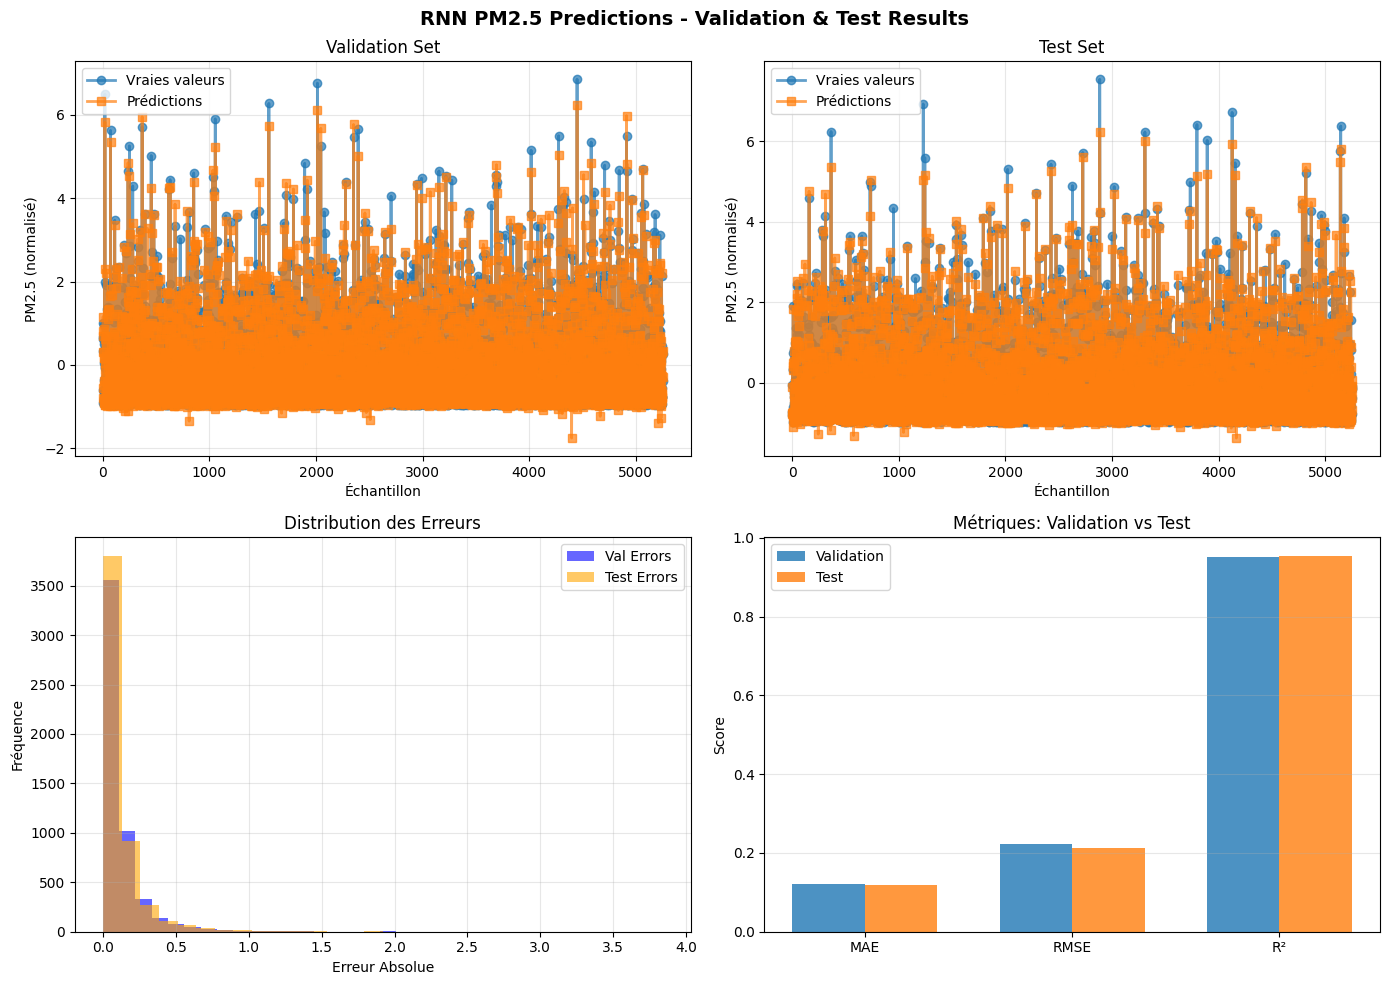

In [7]:
# ============= PREDICTIONS PREVIEW & VISUALIZATIONS =============
import matplotlib.pyplot as plt

# Graphiques
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RNN PM2.5 Predictions - Validation & Test Results', fontsize=14, fontweight='bold')

# 1. Prédictions vs Vraies valeurs (Val)
ax = axes[0, 0]
indices = np.arange(len(final_result['val']['trues']))
ax.plot(indices, final_result['val']['trues'], label='Vraies valeurs', marker='o', alpha=0.7, linewidth=2)
ax.plot(indices, final_result['val']['preds'], label='Prédictions', marker='s', alpha=0.7, linewidth=2)
ax.set_xlabel('Échantillon')
ax.set_ylabel('PM2.5 (normalisé)')
ax.set_title('Validation Set')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Prédictions vs Vraies valeurs (Test)
ax = axes[0, 1]
indices = np.arange(len(final_result['test']['trues']))
ax.plot(indices, final_result['test']['trues'], label='Vraies valeurs', marker='o', alpha=0.7, linewidth=2)
ax.plot(indices, final_result['test']['preds'], label='Prédictions', marker='s', alpha=0.7, linewidth=2)
ax.set_xlabel('Échantillon')
ax.set_ylabel('PM2.5 (normalisé)')
ax.set_title('Test Set')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Distribution des erreurs (Val vs Test)
ax = axes[1, 0]
val_errors = np.abs(final_result['val']['trues'] - final_result['val']['preds'])
test_errors = np.abs(final_result['test']['trues'] - final_result['test']['preds'])
ax.hist(val_errors, bins=30, alpha=0.6, label='Val Errors', color='blue')
ax.hist(test_errors, bins=30, alpha=0.6, label='Test Errors', color='orange')
ax.set_xlabel('Erreur Absolue')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des Erreurs')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Métriques comparées
ax = axes[1, 1]
metrics = ['MAE', 'RMSE', 'R²']
val_scores = [final_result['val']['mae'], final_result['val']['rmse'], final_result['val']['r2']]
test_scores = [final_result['test']['mae'], final_result['test']['rmse'], final_result['test']['r2']]
x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, val_scores, width, label='Validation', alpha=0.8)
ax.bar(x + width/2, test_scores, width, label='Test', alpha=0.8)
ax.set_ylabel('Score')
ax.set_title('Métriques: Validation vs Test')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

